# Daily limit-distance experiments

Compare fixed percentages below the preceding close using both one-session outcomes and recurring monthly cash lots.

In [1]:
%load_ext autoreload
%autoreload 2

import os
from pathlib import Path

import numpy as np
import pandas as pd
import plotly.express as px

from retail_sp500.daily_data import daily_data_summary, load_or_fetch_twelve_data_daily

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.6f}")

from retail_sp500.limit_orders import evaluate_limit_discount_grid
from retail_sp500.limit_portfolio import evaluate_recurring_limit_grid

In [2]:
SYMBOL = "SPY"
START_DATE = "2007-06-01"
CACHE_PATH = Path("data/processed/spy_daily_1day.csv")
REFRESH = False

daily = load_or_fetch_twelve_data_daily(
    os.getenv("TWELVE_DATA_API_KEY"),
    cache_path=CACHE_PATH,
    refresh=REFRESH,
    symbol=SYMBOL,
    start_date=START_DATE,
)

source = daily_data_summary(daily, symbol=SYMBOL)
print(source)
assert source["interval"] == "1day"
assert daily.index.max() <= pd.Timestamp.today().normalize()
daily.tail()

{'source': 'CSV cache: data/processed/spy_daily_1day.csv', 'symbol': 'SPY', 'interval': '1day', 'start': '2007-06-01', 'end': '2026-07-14', 'sessions': 4809}


,open,high,low,close,volume
date,,,,,
2026-07-08,743.159970,746.150020,739.510010,745.400020,43767400
2026-07-09,747.349980,751.969970,745.590030,751.710020,41441700
2026-07-10,752.049988,755.419980,748.099976,754.950010,42191300
2026-07-13,752.469970,753.909970,748.000000,749.169980,44013600
2026-07-14,750.909970,753.299990,748.659970,751.830020,35135286


## Parameter grid

In [3]:
DISCOUNTS = np.arange(0.0, 0.0501, 0.001)
WAIT_HORIZONS = [1, 3, 5, 10, 20]

one_session = evaluate_limit_discount_grid(daily, DISCOUNTS)
recurring = pd.concat(
    [
        evaluate_recurring_limit_grid(
            daily,
            DISCOUNTS,
            max_wait_sessions=wait,
            initial_cash=100_000,
            monthly_contribution=1_000,
        ).assign(wait_horizon=wait)
        for wait in WAIT_HORIZONS
    ],
    ignore_index=True,
)

one_session.sort_values("mean_one_session_excess_vs_open", ascending=False).head(10)

,discount,sessions,fills,fill_rate,gap_fill_rate,mean_fill_discount,median_fill_discount,mean_limit_end_value,mean_market_end_value,mean_one_session_excess_vs_open,unfilled_rising_session_rate
0,0.000000,4808,3809,0.792221,0.454035,0.002837,0.000590,1.000306,1.000157,0.000148,0.830831
1,0.001000,4808,3485,0.724834,0.360649,0.003544,0.001000,1.000192,1.000157,0.000035,0.805745
2,0.002000,4808,3137,0.652454,0.287438,0.004330,0.002000,1.000174,1.000157,0.000017,0.770197
4,0.004000,4808,2458,0.511231,0.180532,0.006080,0.004000,1.000168,1.000157,0.000011,0.711064
3,0.003000,4808,2785,0.579243,0.226082,0.005184,0.003000,1.000158,1.000157,0.000000,0.736530
5,0.005000,4808,2155,0.448211,0.146839,0.007009,0.005000,1.000116,1.000157,-0.000041,0.685262
6,0.006000,4808,1907,0.396631,0.119176,0.007935,0.006000,1.000107,1.000157,-0.000051,0.668735
28,0.028000,4808,180,0.037438,0.004992,0.030042,0.028000,1.000057,1.000157,-0.000101,0.550346
29,0.029000,4808,163,0.033902,0.004368,0.031110,0.029000,1.000052,1.000157,-0.000106,0.548977
7,0.007000,4808,1688,0.351082,0.099002,0.008874,0.007000,1.000044,1.000157,-0.000113,0.657372


## Practical recurring-purchase candidates

Unfilled lots are repriced each session and forced at that session close when their wait horizon expires.

In [4]:
best_by_wait = recurring.loc[
    recurring.groupby("wait_horizon")["ending_excess_value"].idxmax()
].sort_values("wait_horizon")

best_by_wait[[
    "wait_horizon",
    "discount",
    "ending_excess_value",
    "ending_excess_pct_of_contributions",
    "limit_fill_rate",
    "forced_fill_rate",
    "average_wait_sessions",
    "weighted_execution_savings_vs_immediate_open",
]]

,wait_horizon,discount,ending_excess_value,ending_excess_pct_of_contributions,limit_fill_rate,forced_fill_rate,average_wait_sessions,weighted_execution_savings_vs_immediate_open
3,1,0.003000,-417.787647,-0.001270,0.556522,0.443478,1.000000,-0.000051
65,3,0.014000,"4,662.959385",0.014173,0.360870,0.639130,2.552174,0.002984
120,5,0.018000,"12,568.801761",0.038203,0.330435,0.669565,4.130435,0.006974
171,10,0.018000,"11,026.775985",0.033618,0.423581,0.576419,7.253275,0.005188
222,20,0.018000,"10,926.043565",0.033311,0.580786,0.419214,12.200873,0.004893


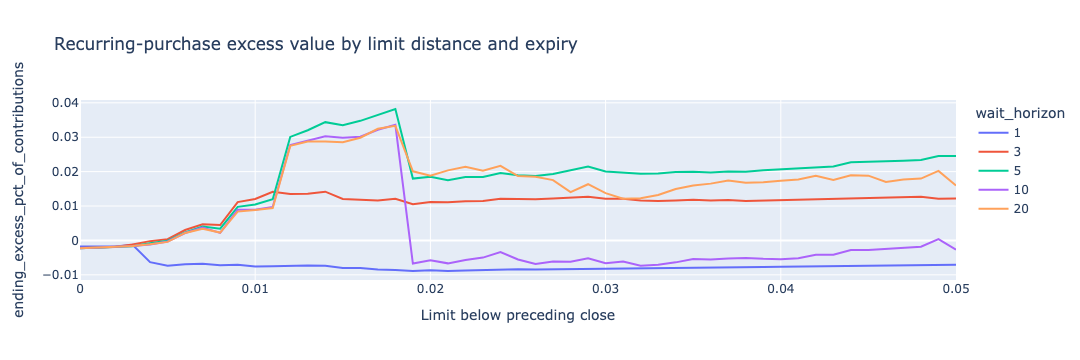

In [5]:
px.line(
    recurring,
    x="discount",
    y="ending_excess_pct_of_contributions",
    color="wait_horizon",
    title="Recurring-purchase excess value by limit distance and expiry",
    labels={"discount": "Limit below preceding close"},
).show()

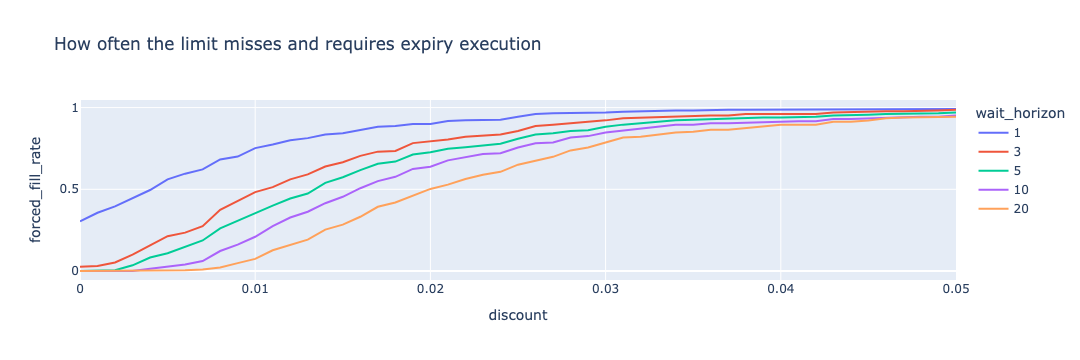

In [6]:
px.line(
    recurring,
    x="discount",
    y="forced_fill_rate",
    color="wait_horizon",
    title="How often the limit misses and requires expiry execution",
).show()

## Interpretation boundary

This is still an execution-only comparison. Dividends, cash yield, spread, fees, taxes, and SGD/USD effects are not included.